In [8]:
import os, random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import transforms
from torchsummary import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split

In [185]:
max_in_class = 200
train_part = 0.5
noise = 0.1
batch_size = 30

epochs = 200
initial_lr = 0.01

device = "cpu"

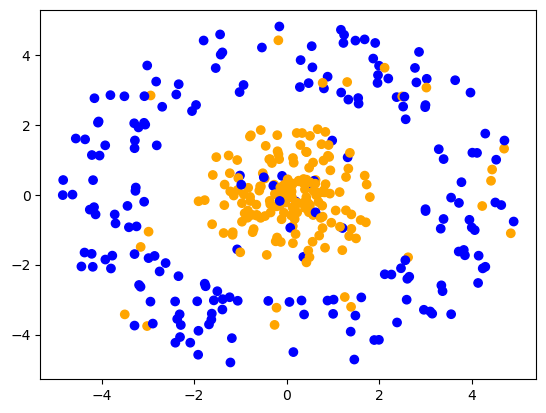

In [187]:
data = []
labels = []

def label_with_noise(label = 0, noise = 0):
    if(random.random() < noise):
        labels.append(1-label)
    else:
        labels.append(label)

n_samples = max_in_class * 2

for i in range(n_samples):
    if i < n_samples / 2:
        radius = random.uniform(3, 5)
        angle = random.uniform(0, 2 * np.pi)
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        data.append([x, y])
        label_with_noise(0, noise)
    else:
        radius = random.uniform(0, 2)
        angle = random.uniform(0, 2 * np.pi)
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        data.append([x, y])
        label_with_noise(1, noise)
data = np.array(data, dtype=np.float32)

x, y = zip(*data)

plt.scatter(x, y,
            c = labels,
            cmap = mcolors.ListedColormap(["b", "orange"]))

In [213]:
class MyDataset(Dataset):
    def __init__(self):
        self.data = torch.tensor(data)
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

dataset = MyDataset()
train_data, test_data = train_test_split(dataset, train_size=train_part, random_state=0)
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)
print(len(train_dataloader.dataset), len(test_dataloader.dataset))

#for batch in dataloader:
#    print("Batch Data:", batch[0])  
#    print("Batch Labels:", batch[1])

200 200


In [239]:
tens_1 = torch.Tensor([[1]]*batch_size)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(1, 2)

    def forward(self, x):
        x = F.softmax(self.fc1(x), dim = 1)
        return x

In [241]:
model = SimpleNN()
#summary(model, (2,1), batch_size, device = device)
print(model)

SimpleNN(
  (fc1): Linear(in_features=1, out_features=2, bias=True)
)


In [243]:
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
loss_fn = nn.CrossEntropyLoss()

In [275]:
def data_prep(X):
    #print(X)
    data_X = []
    for i in range(len(X)):
        data_X.append([np.sqrt((X[i][0])**2 + (X[i][1])**2)])
    return torch.tensor(data_X).to(device)

In [277]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(data_prep(X))
        loss = loss_fn(pred, y)

        train_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    train_loss /= num_batches
    correct /= size

    return correct, train_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(data_prep(X))
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct, test_loss

In [279]:
history = {
    'train_loss':[],
    'train_accuracy':[],
    'val_loss':[],
    'val_accuracy':[],
    'test_loss':[],
    'test_accuracy':[]
}

for t in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    print(f"Epoch {t+1}\n-------------------------------")
    acc, loss = train(train_dataloader, model, loss_fn, optimizer)
    history['train_accuracy'].append(acc)
    history['train_loss'].append(loss)
    acc, loss = test(test_dataloader, model, loss_fn)
    history['val_accuracy'].append(acc)
    history['val_loss'].append(loss)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 88.5%, Avg loss: 0.432008 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 91.0%, Avg loss: 0.421543 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 91.0%, Avg loss: 0.413583 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 91.0%, Avg loss: 0.424722 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 91.0%, Avg loss: 0.423961 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 91.0%, Avg loss: 0.412101 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 91.0%, Avg loss: 0.416280 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 91.0%, Avg loss: 0.411833 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 91.0%, Avg loss: 0.415767 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 91.0%, Avg loss: 0.415588 

Epoch 11
-------------------------------
Test Error: 
 Accuracy: 91.0%, Avg los

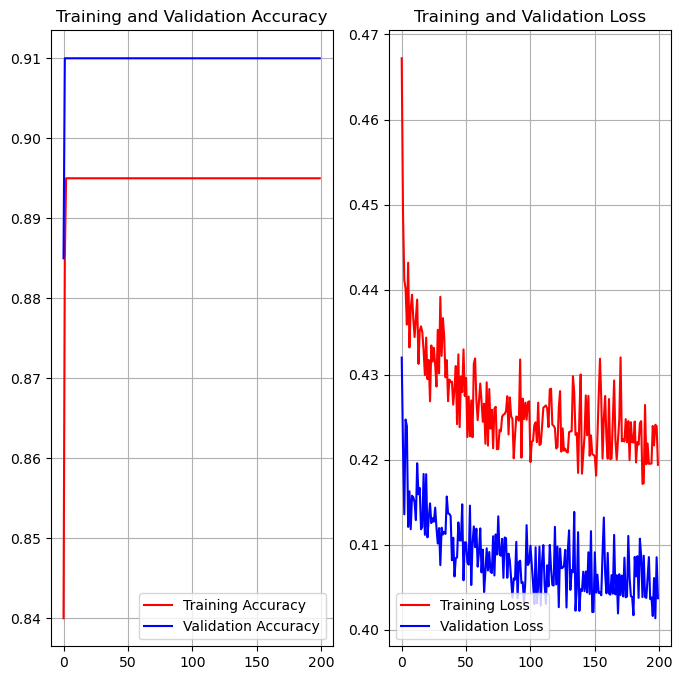

In [280]:
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='lower left')
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

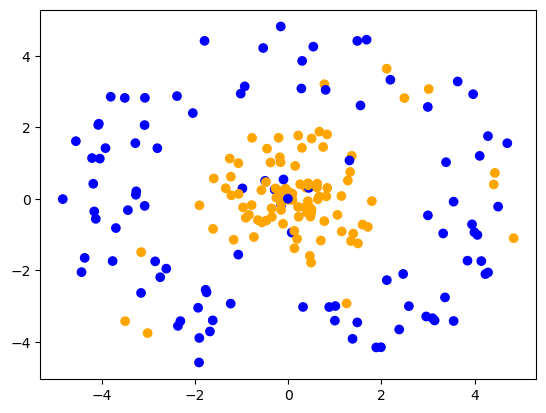

In [281]:
xy, l = zip(*train_dataloader.dataset)
x, y = zip(*xy)

plt.scatter(x, y,
            c = l,
            cmap = mcolors.ListedColormap(["b", "orange"]))

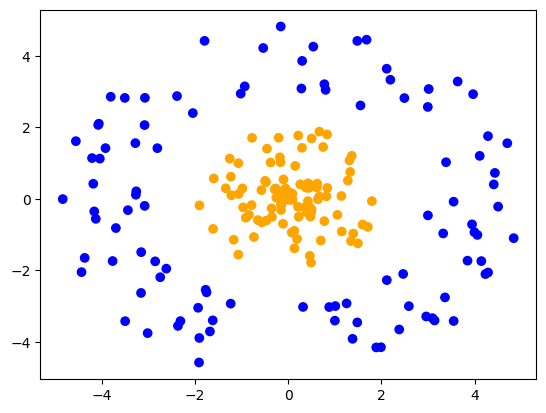

In [285]:
pred = model(data_prep(xy))
plt.scatter(x, y,
            c = pred.argmax(1),
            cmap = mcolors.ListedColormap(["b", "orange"]))

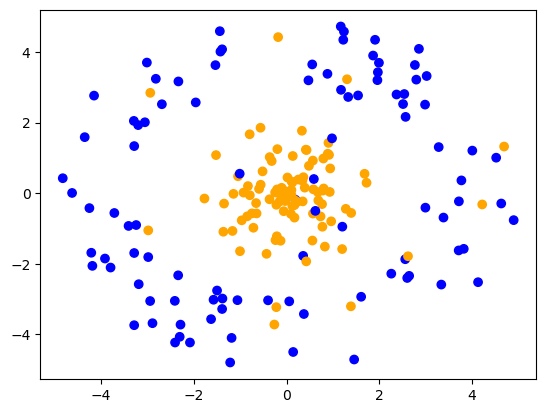

In [287]:
xy, l = zip(*test_dataloader.dataset)
x, y = zip(*xy)

plt.scatter(x, y,
            c = l,
            cmap = mcolors.ListedColormap(["b", "orange"]))

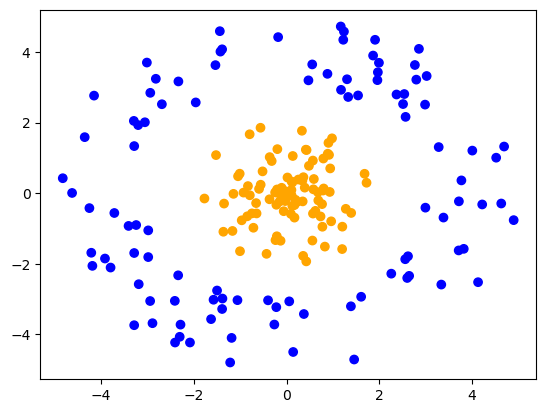

In [289]:
pred = model(data_prep(xy))
plt.scatter(x, y,
            c = pred.argmax(1),
            cmap = mcolors.ListedColormap(["b", "orange"]))